# Stage 4C Notebook — Alcubierre Geometry + Discrete Proper-Time Correction Screening

This notebook is designed to run locally in **Visual Studio Code**. It includes Stage 4A, Stage 4B, and Stage 4C code for numerical curvature extraction and tensor-complete correction screening.

Install dependencies:

```bash
pip install numpy pandas matplotlib scipy ipykernel
```

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from scipy.optimize import least_squares
    SCIPY_AVAILABLE = True
except Exception:
    SCIPY_AVAILABLE = False

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("SciPy available:", SCIPY_AVAILABLE)

NumPy: 2.3.5
Pandas: 2.3.3
SciPy available: True


## Configuration

This version is configured for **DIM = 4** and avoids the two largest allocations in the original notebook:

- `dg` with shape `(dim, dim, dim, N, N, N, N)`
- `dGamma` with shape `(dim, dim, dim, dim, N, N, N, N)`

The default `N` is selected for a 32 GB RAM workstation with a safety margin. You can override `MANUAL_MEMORY_BUDGET_GIB` if you deliberately want to use a larger Windows page file / SSD-backed virtual memory.

In [16]:
# Geometry size and memory policy
DIM = 4                    # 4 = full 3+1 geometry
N_REQUESTED = 81          # requested upper cap; the notebook will choose <= this
MAX_N_CAP = 131

# For the machine shown in the screenshot: 32 GB RAM.
# A full Stage 4A/4B/4C run retains many tensor fields, so the safe RAM budget is below 32 GiB.
# Set this higher only if you intentionally want to use Windows page-file backed virtual memory.
MANUAL_MEMORY_BUDGET_GIB = 28.0

# Conservative estimate for the largest simultaneous field count in this notebook after optimization.
# One scalar field has shape (N, N, N, N). A tensor component is counted as one scalar field.
ESTIMATED_SCALAR_FIELDS_FULL_RUN = 260

R_BUBBLE = 3.0
SIGMA = 1.0
V_S = 0.5
EXTENT = 5.0
T_EXTENT = 0.4
DELTA_TAU = 0.04
INTERIOR_CROP = 3

import math
import gc


def estimate_gib_from_scalar_fields(N, dim=DIM, scalar_fields=ESTIMATED_SCALAR_FIELDS_FULL_RUN, dtype=np.float64):
    """Estimated resident/storage footprint for scalar_fields arrays of shape (N,)*dim."""
    npoints = int(N) ** int(dim)
    bytes_needed = scalar_fields * npoints * np.dtype(dtype).itemsize
    return bytes_needed / 1024**3


def largest_n_for_budget_gib(budget_gib, dim=DIM, scalar_fields=ESTIMATED_SCALAR_FIELDS_FULL_RUN, dtype=np.float64):
    bytes_budget = float(budget_gib) * 1024**3
    n = int((bytes_budget / (scalar_fields * np.dtype(dtype).itemsize)) ** (1.0 / dim))
    return max(3, n)


N_AUTO = largest_n_for_budget_gib(MANUAL_MEMORY_BUDGET_GIB)
N = min(N_REQUESTED, MAX_N_CAP, N_AUTO)

print(f"DIM = {DIM}")
print(f"Requested N cap = {N_REQUESTED}")
print(f"Manual memory budget = {MANUAL_MEMORY_BUDGET_GIB:.1f} GiB")
print(f"Estimated scalar fields = {ESTIMATED_SCALAR_FIELDS_FULL_RUN}")
print(f"Largest RAM-safe N selected = {N}")
print(f"Estimated full-run footprint at N={N}: {estimate_gib_from_scalar_fields(N):.2f} GiB")
print(f"Estimated full-run footprint at requested N={N_REQUESTED}: {estimate_gib_from_scalar_fields(N_REQUESTED):.2f} GiB")


DIM = 4
Requested N cap = 81
Manual memory budget = 28.0 GiB
Estimated scalar fields = 260
Largest RAM-safe N selected = 61
Estimated full-run footprint at N=61: 26.82 GiB
Estimated full-run footprint at requested N=81: 83.39 GiB


## Core functions

In [17]:
def alcubierre_shape(rs: np.ndarray, R: float, sigma: float) -> np.ndarray:
    return (np.tanh(sigma * (rs + R)) - np.tanh(sigma * (rs - R))) / (2.0 * np.tanh(sigma * R))


def make_coordinates(dim: int, N: int, extent: float, t_extent: float):
    if dim == 3:
        coords = [np.linspace(-t_extent, t_extent, N), np.linspace(-extent, extent, N), np.linspace(-extent, extent, N)]
    elif dim == 4:
        coords = [np.linspace(-t_extent, t_extent, N), np.linspace(-extent, extent, N), np.linspace(-extent, extent, N), np.linspace(-extent, extent, N)]
    else:
        raise ValueError("dim must be 3 or 4")
    spacings = [c[1] - c[0] for c in coords]
    return coords, spacings


def make_sparse_mesh(coords):
    """Sparse coordinate mesh: avoids storing full T, X, Y, Z arrays."""
    return np.meshgrid(*coords, indexing="ij", sparse=True)


def compute_rs(mesh, v_s: float, tau_shift: float = 0.0) -> np.ndarray:
    T, X, Y = mesh[0], mesh[1], mesh[2]
    if len(mesh) == 3:
        return np.sqrt((X - v_s * (T + tau_shift))**2 + Y**2)
    Z = mesh[3]
    return np.sqrt((X - v_s * (T + tau_shift))**2 + Y**2 + Z**2)


def finite_proper_time_seed(mesh, R, sigma, v_s, delta_tau):
    f0 = alcubierre_shape(compute_rs(mesh, v_s, 0.0), R, sigma)
    fm = alcubierre_shape(compute_rs(mesh, v_s, -delta_tau), R, sigma)
    fp = alcubierre_shape(compute_rs(mesh, v_s, +delta_tau), R, sigma)
    D2f = (fp - 2.0 * f0 + fm) / (delta_tau**2)
    S = D2f**2
    return f0, D2f, S


## Metric, curvature, and divergence functions

In [18]:
def build_metric(f: np.ndarray, v_s: float, dim: int):
    shape = f.shape
    g = np.zeros((dim, dim) + shape)
    gi = np.zeros_like(g)
    g[0, 0] = -1.0 + v_s**2 * f**2
    g[0, 1] = -v_s * f
    g[1, 0] = -v_s * f
    g[1, 1] = 1.0
    gi[0, 0] = -1.0
    gi[0, 1] = -v_s * f
    gi[1, 0] = -v_s * f
    gi[1, 1] = 1.0 - v_s**2 * f**2
    for a in range(2, dim):
        g[a, a] = 1.0
        gi[a, a] = 1.0
    return g, gi


def grad_axis(A, spacing, axis):
    """Axis-specific gradient. This avoids np.gradient returning all dim derivative arrays."""
    return np.gradient(A, spacing, axis=axis, edge_order=2)


def metric_derivative_cache(g, spacings):
    """Only cache derivatives of nonconstant metric components.

    Original code allocated dg[dim, dim, dim, ...]. For DIM=4, N=131 that alone is ~140 GiB.
    This cache stores only the nonconstant components of the Alcubierre metric.
    """
    dim = g.shape[0]
    shape = g.shape[2:]
    z = np.zeros(shape, dtype=g.dtype)
    cache = {}
    nonconstant = {(0, 0), (0, 1), (1, 0)}
    for a, b in nonconstant:
        for k in range(dim):
            cache[(a, b, k)] = grad_axis(g[a, b], spacings[k], k)

    def dg(a, b, k):
        return cache.get((a, b, k), z)

    return dg


def christoffel_symbols(g, gi, spacings):
    """Memory-optimized Christoffel calculation.

    Does not allocate the full dg tensor. It uses the sparse derivative cache above.
    """
    dim = g.shape[0]
    shape = g.shape[2:]
    dg = metric_derivative_cache(g, spacings)
    Gamma = np.zeros((dim, dim, dim) + shape, dtype=g.dtype)
    for a in range(dim):
        for b in range(dim):
            for c in range(dim):
                total = np.zeros(shape, dtype=g.dtype)
                for l in range(dim):
                    total += gi[a, l] * (dg(c, l, b) + dg(b, l, c) - dg(b, c, l))
                Gamma[a, b, c] = 0.5 * total
    return Gamma


def ricci_and_einstein(g, gi, Gamma, spacings):
    """Memory-optimized Ricci/Einstein calculation.

    Original code allocated dGamma[dim, dim, dim, dim, ...]. For DIM=4, N=131 that would be
    about 560 GiB. This version differentiates one Gamma component at a time.
    """
    dim = g.shape[0]
    shape = g.shape[2:]
    Ricci = np.zeros((dim, dim) + shape, dtype=g.dtype)
    for b in range(dim):
        for c in range(dim):
            total = np.zeros(shape, dtype=g.dtype)
            for a in range(dim):
                total += grad_axis(Gamma[a, b, c], spacings[a], a)
                total -= grad_axis(Gamma[a, b, a], spacings[c], c)
                for d in range(dim):
                    total += Gamma[a, a, d] * Gamma[d, b, c]
                    total -= Gamma[a, c, d] * Gamma[d, b, a]
            Ricci[b, c] = total
            gc.collect()
    R_scalar = np.zeros(shape, dtype=g.dtype)
    for a in range(dim):
        for b in range(dim):
            R_scalar += gi[a, b] * Ricci[a, b]
    Einstein = np.zeros((dim, dim) + shape, dtype=g.dtype)
    for a in range(dim):
        for b in range(dim):
            Einstein[a, b] = Ricci[a, b] - 0.5 * g[a, b] * R_scalar
    return Ricci, R_scalar, Einstein


def mix_tensor_up_down(T_cov, gi):
    dim = T_cov.shape[0]
    Tmix = np.zeros_like(T_cov)
    for a in range(dim):
        for b in range(dim):
            for c in range(dim):
                Tmix[a, b] += gi[a, c] * T_cov[c, b]
    return Tmix


def divergence_mixed(Tmix, Gamma, spacings):
    dim = Tmix.shape[0]
    shape = Tmix.shape[2:]
    C = np.zeros((dim,) + shape, dtype=Tmix.dtype)
    for b in range(dim):
        for a in range(dim):
            C[b] += grad_axis(Tmix[a, b], spacings[a], a)
        for a in range(dim):
            for l in range(dim):
                C[b] += Gamma[a, a, l] * Tmix[l, b]
                C[b] -= Gamma[l, a, b] * Tmix[a, l]
    return C


def l2_norm_tensor(T, crop=3):
    dim = T.shape[0]
    if T.ndim >= 3 and T.shape[1] == dim:
        interior = tuple(slice(crop, -crop) for _ in range(T.ndim - 2))
        return np.sqrt(sum(np.mean(T[a, b][interior]**2) for a in range(dim) for b in range(dim)))
    interior = tuple(slice(crop, -crop) for _ in range(T.ndim - 1))
    return np.sqrt(sum(np.mean(T[a][interior]**2) for a in range(dim)))


## Build geometry

In [19]:
def build_geometry(dim=DIM, N=N, R=R_BUBBLE, sigma=SIGMA, v_s=V_S, extent=EXTENT, t_extent=T_EXTENT, delta_tau=DELTA_TAU):
    print(f"Building geometry with dim={dim}, N={N}")
    print(f"Estimated full-run footprint: {estimate_gib_from_scalar_fields(N, dim=dim):.2f} GiB")
    coords, spacings = make_coordinates(dim, N, extent, t_extent)
    mesh = make_sparse_mesh(coords)
    f0, D2f, S = finite_proper_time_seed(mesh, R, sigma, v_s, delta_tau)
    del mesh
    gc.collect()

    g, gi = build_metric(f0, v_s, dim)
    Gamma = christoffel_symbols(g, gi, spacings)
    Ricci, R_scalar, Einstein = ricci_and_einstein(g, gi, Gamma, spacings)
    Gmix = mix_tensor_up_down(Einstein, gi)
    divG = divergence_mixed(Gmix, Gamma, spacings)
    if dim == 3:
        dfdy = grad_axis(f0, spacings[2], 2)
        rho_A = -(v_s**2)/(32*np.pi)*dfdy**2
    else:
        dfdy = grad_axis(f0, spacings[2], 2)
        dfdz = grad_axis(f0, spacings[3], 3)
        rho_A = -(v_s**2)/(32*np.pi)*(dfdy**2 + dfdz**2)
    return dict(dim=dim, N=N, coords=coords, spacings=spacings, f=f0, D2f=D2f, S=S, g=g, gi=gi, Gamma=Gamma, Ricci=Ricci, R_scalar=R_scalar, Einstein=Einstein, Gmix=Gmix, divG=divG, rho_A=rho_A, sigma=sigma, v_s=v_s, delta_tau=delta_tau)

geom = build_geometry()
print('Built geometry:', geom['dim'], geom['N'], geom['f'].shape)


Building geometry with dim=4, N=61
Estimated full-run footprint: 26.82 GiB
Built geometry: 4 61 (61, 61, 61, 61)


## Stage 4A — Bianchi identity validation

In [20]:
G_l2 = l2_norm_tensor(geom["Gmix"], crop=INTERIOR_CROP)
divG_l2 = l2_norm_tensor(geom["divG"], crop=INTERIOR_CROP)
print("||G^a_b||_2 =", G_l2)
print("||nabla_a G^a_b||_2 =", divG_l2)
print("relative Bianchi residual =", divG_l2 / G_l2 if G_l2 > 0 else np.nan)

||G^a_b||_2 = 0.07482368997848707
||nabla_a G^a_b||_2 = 0.0004513299210893349
relative Bianchi residual = 0.006031912101890444


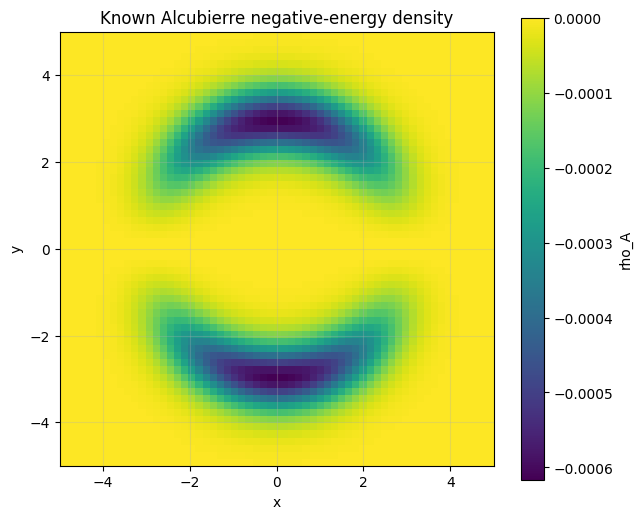

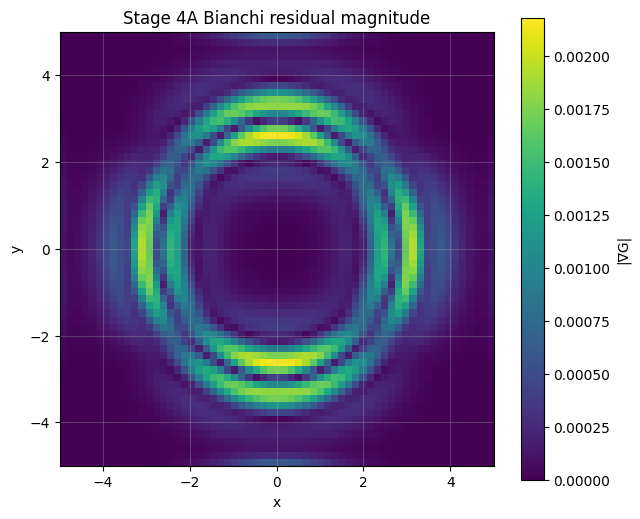

In [21]:
def central_slice(field, geom):
    coords = geom['coords']
    if geom['dim'] == 3:
        t, x, y = coords
        it0 = np.argmin(np.abs(t))
        return field[it0, :, :], x, y
    t, x, y, z = coords
    it0 = np.argmin(np.abs(t))
    iz0 = np.argmin(np.abs(z))
    return field[it0, :, :, iz0], x, y


def plot_central(field, geom, title, label):
    data, x, y = central_slice(field, geom)
    plt.figure(figsize=(7, 6))
    plt.imshow(data.T, extent=[x[0], x[-1], y[0], y[-1]], origin='lower', aspect='equal')
    plt.colorbar(label=label)
    plt.title(title)
    plt.xlabel('x')
    plt.ylabel('y')
    plt.show()

plot_central(geom['rho_A'], geom, 'Known Alcubierre negative-energy density', 'rho_A')
divG_mag = np.sqrt(sum(geom['divG'][a]**2 for a in range(geom['dim'])))
plot_central(divG_mag, geom, 'Stage 4A Bianchi residual magnitude', '|∇G|')

## Stage 4B — Tensor-complete Hessian ansatz

In [22]:
def scalar_hessian(S, geom):
    dim = geom['dim']
    spacings = geom['spacings']
    Gamma = geom['Gamma']
    gi = geom['gi']

    dS = np.zeros((dim,) + S.shape, dtype=S.dtype)
    for a in range(dim):
        dS[a] = grad_axis(S, spacings[a], a)

    Hess = np.zeros((dim, dim) + S.shape, dtype=S.dtype)
    for a in range(dim):
        for b in range(dim):
            Hess[a, b] = grad_axis(dS[a], spacings[b], b)
            for l in range(dim):
                Hess[a, b] -= Gamma[l, a, b] * dS[l]

    BoxS = np.zeros(S.shape, dtype=S.dtype)
    for a in range(dim):
        for b in range(dim):
            BoxS += gi[a, b] * Hess[a, b]

    gradS_up = np.zeros_like(dS)
    for a in range(dim):
        for b in range(dim):
            gradS_up[a] += gi[a, b] * dS[b]
    return dS, gradS_up, Hess, BoxS


def make_Q_candidate(geom, candidate='H', lam=0.0, beta=0.0, aux=None):
    dim = geom['dim']; g = geom['g']; S = geom['S']; Einstein = geom['Einstein']
    if aux is None:
        dS, gradS_up, Hess, BoxS = scalar_hessian(S, geom)
        aux = {'dS': dS, 'gradS_up': gradS_up, 'Hess': Hess, 'BoxS': BoxS}
    else:
        Hess = aux['Hess']; BoxS = aux['BoxS']

    Q = np.zeros((dim, dim) + S.shape, dtype=S.dtype)
    for a in range(dim):
        for b in range(dim):
            Q[a, b] = Hess[a, b] - g[a, b] * BoxS
            if candidate in ('HT','HTR'):
                Q[a, b] -= lam * g[a, b] * S
            if candidate in ('R','HTR'):
                Q[a, b] += beta * S * Einstein[a, b]
    return Q, aux

Q_H, aux_H = make_Q_candidate(geom, candidate='H')
Qmix_H = mix_tensor_up_down(Q_H, geom['gi'])
C_H = divergence_mixed(Qmix_H, geom['Gamma'], geom['spacings'])
Q_l2 = l2_norm_tensor(Qmix_H, crop=INTERIOR_CROP)
C_l2 = l2_norm_tensor(C_H, crop=INTERIOR_CROP)
print('Hessian Q ||Q||:', Q_l2)
print('Hessian Q ||div Q||:', C_l2)
print('C/Q:', C_l2/Q_l2 if Q_l2 > 0 else np.nan)


Hessian Q ||Q||: 0.020324296844360636
Hessian Q ||div Q||: 0.0003846090330492027
C/Q: 0.018923608329206223


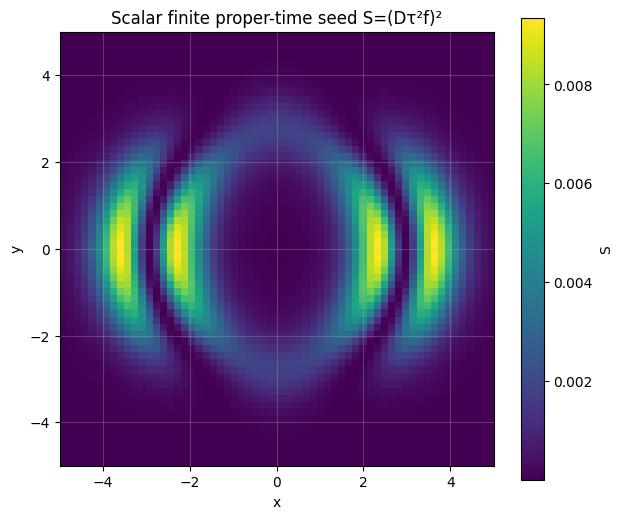

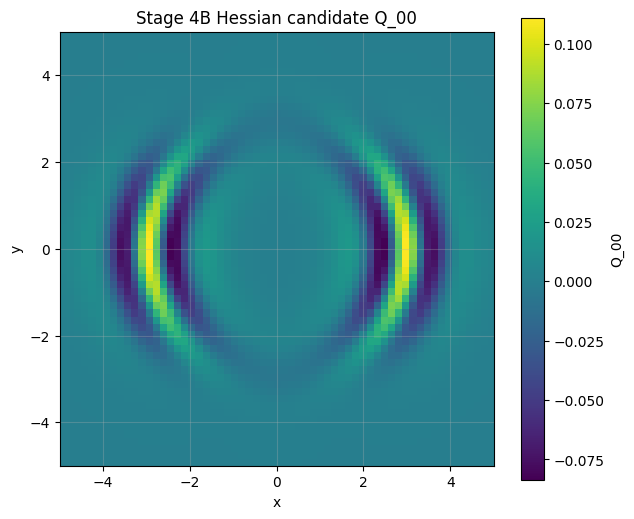

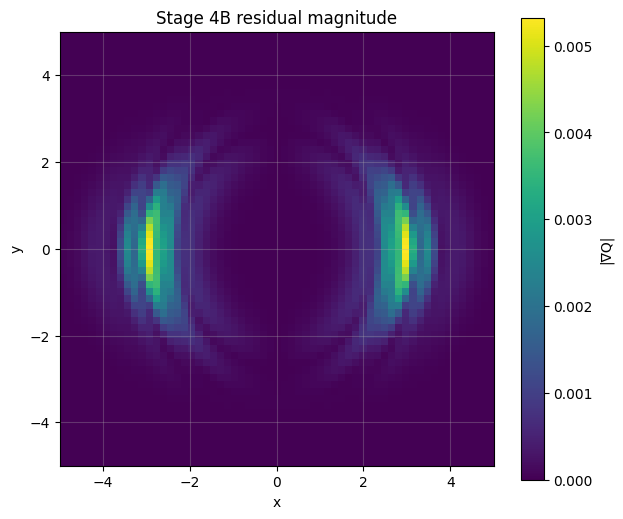

In [23]:
plot_central(geom['S'], geom, 'Scalar finite proper-time seed S=(Dτ²f)²', 'S')
plot_central(Q_H[0,0], geom, 'Stage 4B Hessian candidate Q_00', 'Q_00')
C_H_mag = np.sqrt(sum(C_H[a]**2 for a in range(geom['dim'])))
plot_central(C_H_mag, geom, 'Stage 4B residual magnitude', '|∇Q|')

## Stage 4C — Analytic residual cancellation and candidate ranking

In [24]:
def analytic_residual_components(geom, aux):
    dim = geom['dim']; Ricci = geom['Ricci']; Einstein = geom['Einstein']; gradS_up = aux['gradS_up']; dS = aux['dS']
    A = np.zeros_like(dS); B = dS.copy(); D = np.zeros_like(dS)
    for nu in range(dim):
        for lam in range(dim): A[nu] += Ricci[nu, lam] * gradS_up[lam]
    for nu in range(dim):
        for mu in range(dim): D[nu] += Einstein[mu, nu] * gradS_up[mu]
    return A, B, D


def crop_flat_components(fields, crop=3):
    interior = tuple(slice(crop, -crop) for _ in range(fields.ndim - 1))
    return np.concatenate([fields[a][interior].ravel() for a in range(fields.shape[0])])

A, B, D = analytic_residual_components(geom, aux_H)
a = crop_flat_components(A, INTERIOR_CROP); b = crop_flat_components(B, INTERIOR_CROP); d = crop_flat_components(D, INTERIOR_CROP)
M = np.vstack([-b, d]).T
target = -a
params, residuals, rank, svals = np.linalg.lstsq(M, target, rcond=None)
lambda_fit, beta_fit = params
res_fit = a - lambda_fit*b + beta_fit*d
print('lambda_fit =', lambda_fit)
print('beta_fit =', beta_fit)
print('fit residual ratio =', np.sqrt(np.mean(res_fit**2))/np.sqrt(np.mean(a**2)))

lambda_fit = 0.015789560482987477
beta_fit = -1.0306645653775017
fit residual ratio = 0.5737828338135514


In [25]:
candidate_specs = [
    ('H', 0.0, 0.0, 'H'),
    ('HT', lambda_fit, 0.0, f'HT λ={lambda_fit:.3g}'),
    ('R', 0.0, beta_fit, f'R β={beta_fit:.3g}'),
    ('HTR', lambda_fit, beta_fit, f'HTR λ={lambda_fit:.3g}, β={beta_fit:.3g}'),
    ('HTR', 0.1*lambda_fit, 0.1*beta_fit, f'HTR small λ={0.1*lambda_fit:.3g}, β={0.1*beta_fit:.3g}'),
]
rows = []
for cand, lam, beta, label in candidate_specs:
    Q, _ = make_Q_candidate(geom, candidate=cand, lam=lam, beta=beta, aux=aux_H)
    Qmix = mix_tensor_up_down(Q, geom['gi'])
    C = divergence_mixed(Qmix, geom['Gamma'], geom['spacings'])
    Q_l2 = l2_norm_tensor(Qmix, crop=INTERIOR_CROP)
    C_l2 = l2_norm_tensor(C, crop=INTERIOR_CROP)
    rows.append({'candidate': label, 'lambda': lam, 'beta': beta, 'Q_L2': Q_l2, 'C_L2': C_l2, 'C_over_Q': C_l2/Q_l2 if Q_l2 > 0 else np.nan})
    del Q, Qmix, C
    gc.collect()

df_candidates = pd.DataFrame(rows).sort_values('C_over_Q')
df_candidates


,candidate,lambda,beta,Q_L2,C_L2,C_over_Q
3,"HTR λ=0.0158, β=-1.03",0.015790,-1.030665,0.020335,0.000338,0.016614
2,R β=-1.03,0.000000,-1.030665,0.020355,0.000339,0.016670
4,"HTR small λ=0.00158, β=-0.103",0.001579,-0.103066,0.020325,0.000376,0.018491
1,HT λ=0.0158,0.015790,0.000000,0.020305,0.000380,0.018695
0,H,0.000000,0.000000,0.020324,0.000385,0.018924


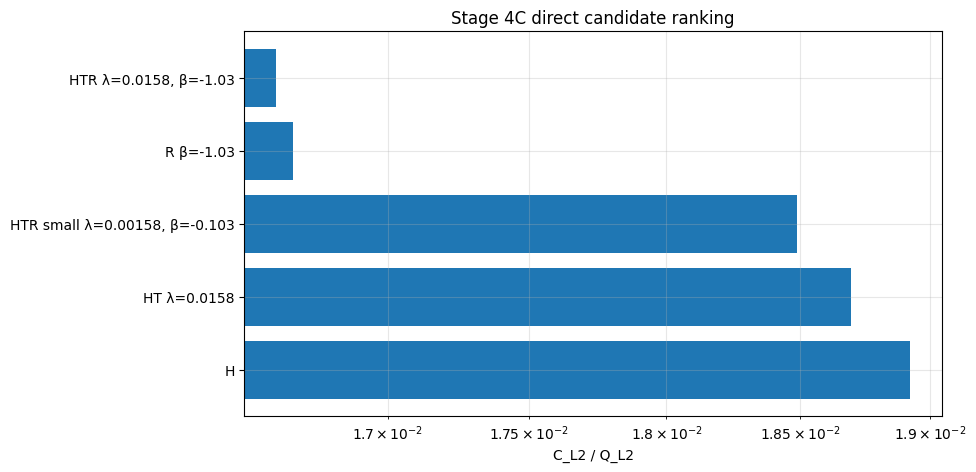

In [26]:
plt.figure(figsize=(9,5))
plt.barh(df_candidates['candidate'], df_candidates['C_over_Q'])
plt.xscale('log')
plt.xlabel('C_L2 / Q_L2')
plt.title('Stage 4C direct candidate ranking')
plt.gca().invert_yaxis()
plt.grid(True, which='both', axis='x', alpha=0.3)
plt.show()

## Optional refinement run

In [27]:
def run_refinement(N_values=(21, 25, 31), dim=DIM):
    rows=[]
    for n in N_values:
        print(f'Running N={n}, dim={dim}...')
        g0 = build_geometry(dim=dim, N=n)
        Q, aux = make_Q_candidate(g0, candidate='H')
        Qmix = mix_tensor_up_down(Q, g0['gi'])
        C = divergence_mixed(Qmix, g0['Gamma'], g0['spacings'])
        G_l2 = l2_norm_tensor(g0['Gmix'], crop=INTERIOR_CROP)
        divG_l2 = l2_norm_tensor(g0['divG'], crop=INTERIOR_CROP)
        Q_l2 = l2_norm_tensor(Qmix, crop=INTERIOR_CROP)
        C_l2 = l2_norm_tensor(C, crop=INTERIOR_CROP)
        A, B, D = analytic_residual_components(g0, aux)
        a = crop_flat_components(A, INTERIOR_CROP); b = crop_flat_components(B, INTERIOR_CROP); d = crop_flat_components(D, INTERIOR_CROP)
        M = np.vstack([-b, d]).T
        params, *_ = np.linalg.lstsq(M, -a, rcond=None)
        lam_fit, beta_fit = params
        res_fit = a - lam_fit*b + beta_fit*d
        rows.append({'N': n, 'dim': dim, 'relative_Bianchi_residual': divG_l2/G_l2 if G_l2 > 0 else np.nan, 'Hessian_Q_C_over_Q': C_l2/Q_l2 if Q_l2 > 0 else np.nan, 'lambda_fit': lam_fit, 'beta_fit': beta_fit, 'analytic_fit_residual_ratio': np.sqrt(np.mean(res_fit**2))/np.sqrt(np.mean(a**2)) if np.mean(a**2)>0 else np.nan})
        del g0, Q, aux, Qmix, C, A, B, D, a, b, d, M
        gc.collect()
    return pd.DataFrame(rows)

# Uncomment to run locally. Keep refinement N values smaller than the main run unless you have a large page file.
# df_refine = run_refinement(N_values=(21,25,31,37), dim=4)
# display(df_refine)


## Interpretation template

1. Stage 4A succeeds if the numerical Bianchi residual for the extracted Einstein tensor is small and decreases with refinement.
2. Stage 4B succeeds as a screening step if the constructed correction tensor is tensor-complete and wall-localized.
3. Stage 4C succeeds as a research step if the analytic residual model identifies curvature-coupled completion terms that reduce the conservation residual.
4. None of these stages proves implementability, exotic-energy cancellation, horizon stability, or chronology protection.

In [28]:
# ============================================================
# EXPORT CELL FOR HTML TECHNICAL ARTICLE UPDATE
# Spinelli / Alcubierre Stage 4A–4C DIM=4 outputs
# ============================================================
#
# Run this as the final cell after the notebook has created:
#   geom
#   Q_H, Qmix_H, C_H, aux_H
#   lambda_fit, beta_fit
#   df_candidates
#
# The cell is defensive: if some variables are missing, it will
# recompute what it needs using functions already defined in the notebook.
#
# Output:
#   ./stage4_dim4_article_exports/
#   ./stage4_dim4_article_exports.zip
#
# Upload the ZIP file back to ChatGPT so I can update the HTML article.
# ============================================================

import os
import json
import math
import time
import gc
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Export configuration
# -----------------------------

EXPORT_DIR = Path("stage4_dim4_article_exports")
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

DPI = 180

# If True, recompute direct C/Q numerical ranking for H, HT, R, HTR.
# This can be memory/time expensive for DIM=4, N=61.
# If you already ran df_candidates successfully, set this False.
RECOMPUTE_DIRECT_CANDIDATES = True

# If recomputing direct candidates is too slow, set this list shorter.
DIRECT_CANDIDATE_SPECS = [
    ("H",   0.0,        0.0,       "H"),
    ("HT",  lambda_fit, 0.0,       f"HT lambda_fit={lambda_fit:.6g}"),
    ("R",   0.0,        beta_fit,  f"R beta_fit={beta_fit:.6g}"),
    ("HTR", lambda_fit, beta_fit,  f"HTR lambda_fit={lambda_fit:.6g}, beta_fit={beta_fit:.6g}"),
]

# -----------------------------
# Helper utilities
# -----------------------------

def savefig(path):
    plt.tight_layout()
    plt.savefig(path, dpi=DPI, bbox_inches="tight")
    plt.close()

def safe_float(x):
    try:
        return float(x)
    except Exception:
        return None

def get_memory_info():
    info = {}
    try:
        import psutil
        vm = psutil.virtual_memory()
        info["machine_RAM_GiB"] = vm.total / (1024**3)
        info["available_RAM_GiB"] = vm.available / (1024**3)
    except Exception:
        info["machine_RAM_GiB"] = None
        info["available_RAM_GiB"] = None
    return info

def get_runtime_info():
    return {
        "python_version": ".".join(map(str, __import__("sys").version_info[:3])),
        "numpy_version": np.__version__,
        "pandas_version": pd.__version__,
    }

def central_slice_scalar(field, geom):
    """
    Return central t=0 and z=0 slice when DIM=4.
    Return central t=0 slice when DIM=3.
    """
    coords = geom["coords"]
    dim = geom["dim"]

    if dim == 3:
        t, x, y = coords
        it0 = int(np.argmin(np.abs(t)))
        return field[it0, :, :], x, y

    if dim == 4:
        t, x, y, z = coords
        it0 = int(np.argmin(np.abs(t)))
        iz0 = int(np.argmin(np.abs(z)))
        return field[it0, :, :, iz0], x, y

    raise ValueError("Only DIM=3 or DIM=4 supported.")

def plot_central_scalar(field, geom, title, colorbar_label, filename, cmap=None):
    data, x, y = central_slice_scalar(field, geom)

    plt.figure(figsize=(7, 6))
    plt.imshow(
        data.T,
        extent=[x[0], x[-1], y[0], y[-1]],
        origin="lower",
        aspect="equal",
        cmap=cmap
    )
    plt.colorbar(label=colorbar_label)
    plt.title(title)
    plt.xlabel("x")
    plt.ylabel("y")
    savefig(EXPORT_DIR / filename)

def l2_scalar(field, crop):
    interior = tuple(slice(crop, -crop) for _ in range(field.ndim))
    return float(np.sqrt(np.mean(field[interior]**2)))

def l2_components(field_components, crop):
    """
    field_components shape:
      (dim, ...) or (dim, dim, ...)
    """
    if field_components.ndim < 2:
        return l2_scalar(field_components, crop)

    tensor_rank = 1 if field_components.ndim == geom["dim"] + 1 else 2
    interior = tuple(slice(crop, -crop) for _ in range(field_components.ndim - tensor_rank))

    if tensor_rank == 1:
        return float(np.sqrt(sum(np.mean(field_components[a][interior]**2) for a in range(field_components.shape[0]))))

    return float(np.sqrt(
        sum(
            np.mean(field_components[a, b][interior]**2)
            for a in range(field_components.shape[0])
            for b in range(field_components.shape[1])
        )
    ))

def compute_rho_from_einstein(geom):
    """
    Eulerian energy density from numerical Einstein tensor:
      rho_num = G_{mu nu} n^mu n^nu / (8 pi)

    For the Alcubierre slicing with lapse alpha=1:
      n^mu = (1, v_s f, 0, 0)
    """
    dim = geom["dim"]
    Einstein = geom["Einstein"]
    f = geom["f"]
    v_s = geom["v_s"]

    n_vec = np.zeros((dim,) + f.shape, dtype=f.dtype)
    n_vec[0] = 1.0
    n_vec[1] = v_s * f

    rho_num = np.zeros(f.shape, dtype=f.dtype)
    for a in range(dim):
        for b in range(dim):
            rho_num += Einstein[a, b] * n_vec[a] * n_vec[b]

    rho_num = rho_num / (8.0 * np.pi)
    return rho_num

def make_residual_magnitude(C):
    return np.sqrt(sum(C[a]**2 for a in range(C.shape[0])))

def make_tensor_candidate_and_score(geom, candidate, lam, beta, aux):
    """
    Uses notebook functions:
      make_Q_candidate
      mix_tensor_up_down
      divergence_mixed
      l2_norm_tensor

    Returns Q, Qmix, C, and score dictionary.
    """
    Q, _ = make_Q_candidate(geom, candidate=candidate, lam=lam, beta=beta, aux=aux)
    Qmix = mix_tensor_up_down(Q, geom["gi"])
    C = divergence_mixed(Qmix, geom["Gamma"], geom["spacings"])

    Q_L2 = float(l2_norm_tensor(Qmix, crop=INTERIOR_CROP))
    C_L2 = float(l2_norm_tensor(C, crop=INTERIOR_CROP))
    C_over_Q = C_L2 / Q_L2 if Q_L2 > 0 else np.nan

    score = {
        "candidate": candidate,
        "lambda": float(lam),
        "beta": float(beta),
        "Q_L2": Q_L2,
        "C_L2": C_L2,
        "C_over_Q": C_over_Q,
        "normalized_residual": C_over_Q,
    }

    return Q, Qmix, C, score

# -----------------------------
# Validate expected notebook state
# -----------------------------

required_names = ["geom", "INTERIOR_CROP"]
missing = [name for name in required_names if name not in globals()]
if missing:
    raise RuntimeError(
        f"Missing required notebook variables: {missing}. "
        "Run the geometry-building cells first."
    )

DIM_LOCAL = int(geom["dim"])
N_LOCAL = int(geom["N"])

print(f"Exporting Stage 4 outputs for DIM={DIM_LOCAL}, N={N_LOCAL}")
print(f"Export directory: {EXPORT_DIR.resolve()}")

# -----------------------------
# Metadata
# -----------------------------

metadata = {
    "DIM": DIM_LOCAL,
    "N": N_LOCAL,
    "R_BUBBLE": safe_float(globals().get("R_BUBBLE", None)),
    "SIGMA": safe_float(globals().get("SIGMA", geom.get("sigma", None))),
    "V_S": safe_float(globals().get("V_S", geom.get("v_s", None))),
    "EXTENT": safe_float(globals().get("EXTENT", None)),
    "T_EXTENT": safe_float(globals().get("T_EXTENT", None)),
    "DELTA_TAU": safe_float(globals().get("DELTA_TAU", geom.get("delta_tau", None))),
    "INTERIOR_CROP": int(INTERIOR_CROP),
    "estimated_full_run_GiB": safe_float(
        estimate_gib_from_scalar_fields(N_LOCAL, dim=DIM_LOCAL)
        if "estimate_gib_from_scalar_fields" in globals()
        else None
    ),
    "notes": "Generated by final export cell for HTML technical article update.",
}
metadata.update(get_memory_info())
metadata.update(get_runtime_info())

with open(EXPORT_DIR / "run_metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2)

pd.DataFrame([metadata]).to_csv(EXPORT_DIR / "run_metadata.csv", index=False)

# -----------------------------
# Stage 4A exports
# -----------------------------

print("Stage 4A exports...")

rho_num = compute_rho_from_einstein(geom)
rho_A = geom["rho_A"]
rho_error = rho_num - rho_A

G_L2 = float(l2_norm_tensor(geom["Gmix"], crop=INTERIOR_CROP))
divG_L2 = float(l2_norm_tensor(geom["divG"], crop=INTERIOR_CROP))
relative_Bianchi_residual = divG_L2 / G_L2 if G_L2 > 0 else np.nan

interior = tuple(slice(INTERIOR_CROP, -INTERIOR_CROP) for _ in range(rho_A.ndim))
rho_peak_error = float(np.max(np.abs(rho_error[interior])))
rho_peak_analytic = float(np.max(np.abs(rho_A[interior])))
rho_relative_peak_error = rho_peak_error / rho_peak_analytic if rho_peak_analytic > 0 else np.nan

spacing_values = geom["spacings"]
stage4A_row = {
    "DIM": DIM_LOCAL,
    "N": N_LOCAL,
    "dt": float(spacing_values[0]),
    "dx": float(spacing_values[1]) if DIM_LOCAL >= 2 else np.nan,
    "dy": float(spacing_values[2]) if DIM_LOCAL >= 3 else np.nan,
    "dz": float(spacing_values[3]) if DIM_LOCAL >= 4 else np.nan,
    "G_L2": G_L2,
    "divG_L2": divG_L2,
    "relative_Bianchi_residual": relative_Bianchi_residual,
    "rho_num_min": float(np.min(rho_num[interior])),
    "rho_num_max": float(np.max(rho_num[interior])),
    "rho_A_min": float(np.min(rho_A[interior])),
    "rho_A_max": float(np.max(rho_A[interior])),
    "rho_relative_peak_error": rho_relative_peak_error,
}

pd.DataFrame([stage4A_row]).to_csv(
    EXPORT_DIR / "stage4A_dim4_bianchi_validation.csv",
    index=False
)

plot_central_scalar(
    rho_num,
    geom,
    "Stage 4A DIM=4: rho extracted from numerical Einstein tensor",
    "rho_num",
    "stage4A_dim4_rho_from_einstein_tensor.png"
)

plot_central_scalar(
    rho_A,
    geom,
    "Stage 4A DIM=4: known Alcubierre negative-energy density",
    "rho_A",
    "stage4A_dim4_known_rho_A.png"
)

plot_central_scalar(
    rho_error,
    geom,
    "Stage 4A DIM=4: Einstein-tensor extraction error map",
    "rho_num - rho_A",
    "stage4A_dim4_rho_error_map.png"
)

divG_mag = make_residual_magnitude(geom["divG"])
plot_central_scalar(
    divG_mag,
    geom,
    "Stage 4A DIM=4: numerical Bianchi residual magnitude",
    "|nabla_mu G^mu_nu|",
    "stage4A_dim4_bianchi_residual_map.png"
)

# Optional refinement CSV/plots if variable exists
if "df_refine" in globals() and isinstance(df_refine, pd.DataFrame):
    df_refine.to_csv(EXPORT_DIR / "stage4C_dim4_refinement.csv", index=False)

    if "relative_Bianchi_residual" in df_refine.columns:
        plt.figure(figsize=(8, 5))
        plt.plot(df_refine["N"], df_refine["relative_Bianchi_residual"], marker="o")
        plt.yscale("log")
        plt.title("Stage 4A DIM=4: Bianchi residual under refinement")
        plt.xlabel("Grid size N")
        plt.ylabel("relative Bianchi residual")
        plt.grid(True, which="both", alpha=0.3)
        savefig(EXPORT_DIR / "stage4A_dim4_bianchi_refinement.png")

    if "rho_relative_peak_error" in df_refine.columns:
        plt.figure(figsize=(8, 5))
        plt.plot(df_refine["N"], df_refine["rho_relative_peak_error"], marker="o")
        plt.yscale("log")
        plt.title("Stage 4A DIM=4: rho extraction error under refinement")
        plt.xlabel("Grid size N")
        plt.ylabel("relative peak error in rho")
        plt.grid(True, which="both", alpha=0.3)
        savefig(EXPORT_DIR / "stage4A_dim4_rho_error_refinement.png")

# -----------------------------
# Stage 4B exports
# -----------------------------

print("Stage 4B exports...")

if "Q_H" not in globals() or "aux_H" not in globals():
    print("Q_H or aux_H missing; recomputing Hessian candidate.")
    Q_H, aux_H = make_Q_candidate(geom, candidate="H")

if "Qmix_H" not in globals():
    Qmix_H = mix_tensor_up_down(Q_H, geom["gi"])

if "C_H" not in globals():
    C_H = divergence_mixed(Qmix_H, geom["Gamma"], geom["spacings"])

Q_L2_H = float(l2_norm_tensor(Qmix_H, crop=INTERIOR_CROP))
C_L2_H = float(l2_norm_tensor(C_H, crop=INTERIOR_CROP))
normalized_Q_residual_H = C_L2_H / Q_L2_H if Q_L2_H > 0 else np.nan

S_peak = float(np.max(geom["S"][interior]))
Q00_peak_abs = float(np.max(np.abs(Q_H[0, 0][interior])))
C_H_mag = make_residual_magnitude(C_H)
C_peak = float(np.max(C_H_mag[interior]))

stage4B_row = {
    "DIM": DIM_LOCAL,
    "N": N_LOCAL,
    "Q_L2": Q_L2_H,
    "C_L2": C_L2_H,
    "normalized_Q_conservation_residual": normalized_Q_residual_H,
    "S_peak": S_peak,
    "Q00_peak_abs": Q00_peak_abs,
    "C_peak": C_peak,
}

pd.DataFrame([stage4B_row]).to_csv(
    EXPORT_DIR / "stage4B_dim4_hessian_Q_proxy.csv",
    index=False
)

plot_central_scalar(
    geom["S"],
    geom,
    "Stage 4B DIM=4: scalar seed S = (D_tau^2 f)^2",
    "S",
    "stage4B_dim4_scalar_seed_S.png"
)

plot_central_scalar(
    Q_H[0, 0],
    geom,
    "Stage 4B DIM=4: Hessian candidate Q_00",
    "Q_H_00",
    "stage4B_dim4_Q00_hessian_candidate.png"
)

plot_central_scalar(
    C_H_mag,
    geom,
    "Stage 4B DIM=4: Hessian candidate residual magnitude",
    "|nabla_mu Q^mu_nu|",
    "stage4B_dim4_Q_residual_magnitude.png"
)

# Q00 vs rhoA central x=0 line cut
Q00_slice, xs, ys = central_slice_scalar(Q_H[0, 0], geom)
rho_slice, _, _ = central_slice_scalar(rho_A, geom)

ix0 = int(np.argmin(np.abs(xs)))
rho_cut = rho_slice[ix0, :]
Q_cut = Q00_slice[ix0, :]

rho_norm = rho_cut / np.max(np.abs(rho_cut)) if np.max(np.abs(rho_cut)) > 0 else rho_cut
Q_norm = Q_cut / np.max(np.abs(Q_cut)) if np.max(np.abs(Q_cut)) > 0 else Q_cut

plt.figure(figsize=(8, 5))
plt.plot(ys, rho_norm, label="rho_A / max|rho_A|")
plt.plot(ys, Q_norm, label="Q_H_00 / max|Q_H_00|")
plt.title("Stage 4B DIM=4: Hessian Q_00 versus classical rho_A at x=0")
plt.xlabel("y")
plt.ylabel("normalized amplitude")
plt.legend()
plt.grid(True, alpha=0.3)
savefig(EXPORT_DIR / "stage4B_dim4_Q00_vs_rhoA_cut.png")

# -----------------------------
# Stage 4C analytic residual exports
# -----------------------------

print("Stage 4C analytic residual exports...")

if "lambda_fit" not in globals() or "beta_fit" not in globals():
    print("lambda_fit or beta_fit missing; computing analytic residual fit.")
    A, B, D = analytic_residual_components(geom, aux_H)
    a = crop_flat_components(A, INTERIOR_CROP)
    b = crop_flat_components(B, INTERIOR_CROP)
    d = crop_flat_components(D, INTERIOR_CROP)
    M = np.vstack([-b, d]).T
    target = -a
    params, *_ = np.linalg.lstsq(M, target, rcond=None)
    lambda_fit, beta_fit = params
else:
    A, B, D = analytic_residual_components(geom, aux_H)
    a = crop_flat_components(A, INTERIOR_CROP)
    b = crop_flat_components(B, INTERIOR_CROP)
    d = crop_flat_components(D, INTERIOR_CROP)

res_H = a
res_HT = a - lambda_fit * b
res_R = a + beta_fit * d
res_HTR = a - lambda_fit * b + beta_fit * d

def rms(v):
    return float(np.sqrt(np.mean(v**2)))

residual_H = rms(res_H)
residual_HT = rms(res_HT)
residual_R = rms(res_R)
residual_HTR = rms(res_HTR)

stage4C_fit_row = {
    "DIM": DIM_LOCAL,
    "N": N_LOCAL,
    "lambda_fit": float(lambda_fit),
    "beta_fit": float(beta_fit),
    "residual_H": residual_H,
    "residual_HT_lambda_fit": residual_HT,
    "residual_R_beta_fit": residual_R,
    "residual_HTR_lambda_beta_fit": residual_HTR,
    "improvement_HT_over_H": 1.0 - residual_HT / residual_H if residual_H > 0 else np.nan,
    "improvement_R_over_H": 1.0 - residual_R / residual_H if residual_H > 0 else np.nan,
    "improvement_HTR_over_H": 1.0 - residual_HTR / residual_H if residual_H > 0 else np.nan,
}

pd.DataFrame([stage4C_fit_row]).to_csv(
    EXPORT_DIR / "stage4C_dim4_fit_parameters.csv",
    index=False
)

# Residual cancellation components plot
component_names = [
    "H residual A",
    "HT residual A - lambda B",
    "R residual A + beta D",
    "HTR residual A - lambda B + beta D",
]
component_values = [residual_H, residual_HT, residual_R, residual_HTR]

plt.figure(figsize=(9, 5))
plt.barh(component_names, component_values)
plt.xscale("log")
plt.title("Stage 4C DIM=4: analytic residual cancellation components")
plt.xlabel("RMS residual")
plt.gca().invert_yaxis()
plt.grid(True, which="both", axis="x", alpha=0.3)
savefig(EXPORT_DIR / "stage4C_dim4_residual_cancellation_components.png")

# -----------------------------
# Stage 4C direct candidate ranking
# -----------------------------

print("Stage 4C direct candidate ranking exports...")

df_direct_candidates = None
candidate_details = {}

if (not RECOMPUTE_DIRECT_CANDIDATES) and "df_candidates" in globals():
    df_direct_candidates = df_candidates.copy()
    # Normalize expected column names
    if "C_over_Q" in df_direct_candidates.columns and "normalized_residual" not in df_direct_candidates.columns:
        df_direct_candidates["normalized_residual"] = df_direct_candidates["C_over_Q"]
    print("Using existing df_candidates table.")
else:
    rows = []

    for candidate, lam, beta, label in DIRECT_CANDIDATE_SPECS:
        print(f"Computing direct candidate: {label}")
        t0 = time.time()

        Q, Qmix, C, score = make_tensor_candidate_and_score(
            geom,
            candidate=candidate,
            lam=lam,
            beta=beta,
            aux=aux_H
        )

        score["candidate"] = label
        rows.append(score)

        candidate_details[label] = {
            "Q": Q,
            "Qmix": Qmix,
            "C": C,
        }

        print(f"  done in {time.time() - t0:.1f} s, C/Q={score['C_over_Q']:.6g}")

        # Do not delete best candidates yet; need for plots.
        gc.collect()

    df_direct_candidates = pd.DataFrame(rows)

df_direct_candidates = df_direct_candidates.sort_values("normalized_residual").reset_index(drop=True)
df_direct_candidates["rank"] = np.arange(1, len(df_direct_candidates) + 1)

df_direct_candidates.to_csv(
    EXPORT_DIR / "stage4C_dim4_candidate_ranking.csv",
    index=False
)

# Ranking plot
plt.figure(figsize=(9, 5))
plt.barh(df_direct_candidates["candidate"], df_direct_candidates["normalized_residual"])
plt.xscale("log")
plt.title("Stage 4C DIM=4: direct candidate ranking")
plt.xlabel("normalized conservation residual")
plt.gca().invert_yaxis()
plt.grid(True, which="both", axis="x", alpha=0.3)
savefig(EXPORT_DIR / "stage4C_dim4_candidate_ranking.png")

# Best candidate maps
best_candidate_label = str(df_direct_candidates.iloc[0]["candidate"])
print("Best direct candidate:", best_candidate_label)

if best_candidate_label not in candidate_details:
    # Recompute only the best candidate if using preexisting df_candidates.
    # Try to infer candidate type from label.
    if best_candidate_label.startswith("H ") or best_candidate_label == "H":
        cand, lam, beta = "H", 0.0, 0.0
    elif best_candidate_label.startswith("HTR"):
        cand, lam, beta = "HTR", lambda_fit, beta_fit
    elif best_candidate_label.startswith("HT"):
        cand, lam, beta = "HT", lambda_fit, 0.0
    elif best_candidate_label.startswith("R"):
        cand, lam, beta = "R", 0.0, beta_fit
    else:
        # Conservative fallback
        cand, lam, beta = "HTR", lambda_fit, beta_fit

    Q_best, Qmix_best, C_best, _ = make_tensor_candidate_and_score(
        geom,
        candidate=cand,
        lam=lam,
        beta=beta,
        aux=aux_H
    )
else:
    Q_best = candidate_details[best_candidate_label]["Q"]
    C_best = candidate_details[best_candidate_label]["C"]

C_best_mag = make_residual_magnitude(C_best)

plot_central_scalar(
    Q_best[0, 0],
    geom,
    f"Stage 4C DIM=4: best candidate Q_00 ({best_candidate_label})",
    "Q_best_00",
    "stage4C_dim4_best_Q00.png"
)

plot_central_scalar(
    C_best_mag,
    geom,
    f"Stage 4C DIM=4: best candidate residual magnitude ({best_candidate_label})",
    "|nabla_mu Q^mu_nu|",
    "stage4C_dim4_best_residual_map.png"
)

# Best Q00 vs rhoA central x=0 line cut
Qbest_slice, xs, ys = central_slice_scalar(Q_best[0, 0], geom)
rho_slice, _, _ = central_slice_scalar(rho_A, geom)

ix0 = int(np.argmin(np.abs(xs)))
rho_cut = rho_slice[ix0, :]
Q_cut = Qbest_slice[ix0, :]

rho_norm = rho_cut / np.max(np.abs(rho_cut)) if np.max(np.abs(rho_cut)) > 0 else rho_cut
Q_norm = Q_cut / np.max(np.abs(Q_cut)) if np.max(np.abs(Q_cut)) > 0 else Q_cut

plt.figure(figsize=(8, 5))
plt.plot(ys, rho_norm, label="rho_A / max|rho_A|")
plt.plot(ys, Q_norm, label=f"{best_candidate_label} Q_00 / max|Q_00|")
plt.title("Stage 4C DIM=4: best Q_00 proxy versus classical rho_A at x=0")
plt.xlabel("y")
plt.ylabel("normalized amplitude")
plt.legend()
plt.grid(True, alpha=0.3)
savefig(EXPORT_DIR / "stage4C_dim4_best_Q00_vs_rhoA_cut.png")

# -----------------------------
# Summary README
# -----------------------------

readme = f"""# Stage 4 DIM=4 article export package

Generated for updating the HTML technical article.

DIM = {DIM_LOCAL}
N = {N_LOCAL}

Main CSV files:
- run_metadata.csv
- stage4A_dim4_bianchi_validation.csv
- stage4B_dim4_hessian_Q_proxy.csv
- stage4C_dim4_fit_parameters.csv
- stage4C_dim4_candidate_ranking.csv

Main PNG files:
- stage4A_dim4_rho_from_einstein_tensor.png
- stage4A_dim4_known_rho_A.png
- stage4A_dim4_rho_error_map.png
- stage4A_dim4_bianchi_residual_map.png
- stage4B_dim4_scalar_seed_S.png
- stage4B_dim4_Q00_hessian_candidate.png
- stage4B_dim4_Q_residual_magnitude.png
- stage4B_dim4_Q00_vs_rhoA_cut.png
- stage4C_dim4_candidate_ranking.png
- stage4C_dim4_residual_cancellation_components.png
- stage4C_dim4_best_Q00.png
- stage4C_dim4_best_residual_map.png
- stage4C_dim4_best_Q00_vs_rhoA_cut.png

Best direct candidate:
{best_candidate_label}

Stage 4A:
relative_Bianchi_residual = {relative_Bianchi_residual}
rho_relative_peak_error = {rho_relative_peak_error}

Stage 4B:
Hessian normalized_Q_conservation_residual = {normalized_Q_residual_H}

Stage 4C:
lambda_fit = {lambda_fit}
beta_fit = {beta_fit}
analytic HTR improvement over H = {stage4C_fit_row["improvement_HTR_over_H"]}
"""

with open(EXPORT_DIR / "README.txt", "w", encoding="utf-8") as f:
    f.write(readme)

# -----------------------------
# Zip the export folder
# -----------------------------

zip_path = Path(str(EXPORT_DIR) + ".zip")
if zip_path.exists():
    zip_path.unlink()

with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zf:
    for file_path in EXPORT_DIR.rglob("*"):
        zf.write(file_path, arcname=file_path.relative_to(EXPORT_DIR))

print("\nEXPORT COMPLETE")
print("Folder:", EXPORT_DIR.resolve())
print("ZIP:", zip_path.resolve())
print("\nPlease upload this ZIP file back here:")
print(zip_path.resolve())

# Display final key tables in notebook
display(pd.DataFrame([stage4A_row]))
display(pd.DataFrame([stage4B_row]))
display(pd.DataFrame([stage4C_fit_row]))
display(df_direct_candidates)

Exporting Stage 4 outputs for DIM=4, N=61
Export directory: C:\Users\spine\Documents\LaTeXProjects\Alcubierre test of the Spinelli Framework for discrete time\Stage 4C test\stage4_dim4_article_exports
Stage 4A exports...
Stage 4B exports...
Stage 4C analytic residual exports...
Stage 4C direct candidate ranking exports...
Computing direct candidate: H
  done in 105.6 s, C/Q=0.0189236
Computing direct candidate: HT lambda_fit=0.0157896
  done in 83.1 s, C/Q=0.0186947
Computing direct candidate: R beta_fit=-1.03066
  done in 114.6 s, C/Q=0.0166704
Computing direct candidate: HTR lambda_fit=0.0157896, beta_fit=-1.03066
  done in 69.8 s, C/Q=0.0166144
Best direct candidate: HTR lambda_fit=0.0157896, beta_fit=-1.03066

EXPORT COMPLETE
Folder: C:\Users\spine\Documents\LaTeXProjects\Alcubierre test of the Spinelli Framework for discrete time\Stage 4C test\stage4_dim4_article_exports
ZIP: C:\Users\spine\Documents\LaTeXProjects\Alcubierre test of the Spinelli Framework for discrete time\Stage 4

,DIM,N,dt,dx,dy,dz,G_L2,divG_L2,relative_Bianchi_residual,rho_num_min,rho_num_max,rho_A_min,rho_A_max,rho_relative_peak_error
0,4,61,0.013333,0.166667,0.166667,0.166667,0.074824,0.000451,0.006032,-0.000601,-2.118899e-11,-0.00062,-0.0,0.049646


,DIM,N,Q_L2,C_L2,normalized_Q_conservation_residual,S_peak,Q00_peak_abs,C_peak
0,4,61,0.020324,0.000385,0.018924,0.009353,0.111408,0.005328


,DIM,N,lambda_fit,beta_fit,residual_H,residual_HT_lambda_fit,residual_R_beta_fit,residual_HTR_lambda_beta_fit,improvement_HT_over_H,improvement_R_over_H,improvement_HTR_over_H
0,4,61,0.01579,-1.030665,0.000117,0.000111,0.000072,0.000067,0.052497,0.38376,0.426217


,candidate,lambda,beta,Q_L2,C_L2,C_over_Q,normalized_residual,rank
0,"HTR lambda_fit=0.0157896, beta_fit=-1.03066",0.01579,-1.030665,0.020335,0.000338,0.016614,0.016614,1
1,R beta_fit=-1.03066,0.00000,-1.030665,0.020355,0.000339,0.016670,0.016670,2
2,HT lambda_fit=0.0157896,0.01579,0.000000,0.020305,0.000380,0.018695,0.018695,3
3,H,0.00000,0.000000,0.020324,0.000385,0.018924,0.018924,4


In [ ]:
# ============================================================
# STAGE 4D / ACTION-DERIVED Q TEST
# Compare:
#   1. Best fitted HTR tensor
#   2. Action-predicted tensor with beta = -1
#   3. Difference between them
#
# Requires notebook state:
#   geom
#   aux_H
#   lambda_fit
#   beta_fit
#   INTERIOR_CROP
#   make_Q_candidate
#   mix_tensor_up_down
#   divergence_mixed
#   l2_norm_tensor
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import zipfile
import json
import gc

EXPORT_DIR = Path("stage4D_action_Q_comparison_exports")
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

DPI = 180

BETA_ACTION = -1.0
LAMBDA_ACTION = float(lambda_fit)   # Use the same fitted lambda; action fixes beta, not lambda.
BETA_FIT = float(beta_fit)
LAMBDA_FIT = float(lambda_fit)

print("Stage 4D action-derived Q comparison")
print(f"lambda_fit  = {LAMBDA_FIT}")
print(f"beta_fit    = {BETA_FIT}")
print(f"beta_action = {BETA_ACTION}")


# -----------------------------
# Helpers
# -----------------------------

def savefig(path):
    plt.tight_layout()
    plt.savefig(path, dpi=DPI, bbox_inches="tight")
    plt.close()

def central_slice_scalar(field, geom):
    coords = geom["coords"]
    dim = geom["dim"]

    if dim == 3:
        t, x, y = coords
        it0 = int(np.argmin(np.abs(t)))
        return field[it0, :, :], x, y

    if dim == 4:
        t, x, y, z = coords
        it0 = int(np.argmin(np.abs(t)))
        iz0 = int(np.argmin(np.abs(z)))
        return field[it0, :, :, iz0], x, y

    raise ValueError("Only DIM=3 or DIM=4 supported.")

def plot_central_scalar(field, geom, title, colorbar_label, filename):
    data, x, y = central_slice_scalar(field, geom)

    plt.figure(figsize=(7, 6))
    plt.imshow(
        data.T,
        extent=[x[0], x[-1], y[0], y[-1]],
        origin="lower",
        aspect="equal"
    )
    plt.colorbar(label=colorbar_label)
    plt.title(title)
    plt.xlabel("x")
    plt.ylabel("y")
    savefig(EXPORT_DIR / filename)

def residual_magnitude(C):
    return np.sqrt(sum(C[a]**2 for a in range(C.shape[0])))

def score_Q(label, Q_cov):
    Q_mix = mix_tensor_up_down(Q_cov, geom["gi"])
    C = divergence_mixed(Q_mix, geom["Gamma"], geom["spacings"])

    Q_L2 = float(l2_norm_tensor(Q_mix, crop=INTERIOR_CROP))
    C_L2 = float(l2_norm_tensor(C, crop=INTERIOR_CROP))
    C_over_Q = C_L2 / Q_L2 if Q_L2 > 0 else np.nan

    return {
        "label": label,
        "Q_cov": Q_cov,
        "Q_mix": Q_mix,
        "C": C,
        "Q_L2": Q_L2,
        "C_L2": C_L2,
        "normalized_residual": C_over_Q,
    }

def relative_tensor_difference(Q_A, Q_B):
    """
    Return ||Q_A - Q_B|| / ||Q_B|| using mixed tensors.
    """
    Q_A_mix = mix_tensor_up_down(Q_A, geom["gi"])
    Q_B_mix = mix_tensor_up_down(Q_B, geom["gi"])
    D_mix = Q_A_mix - Q_B_mix

    D_L2 = float(l2_norm_tensor(D_mix, crop=INTERIOR_CROP))
    B_L2 = float(l2_norm_tensor(Q_B_mix, crop=INTERIOR_CROP))

    return D_L2 / B_L2 if B_L2 > 0 else np.nan, D_L2, B_L2


# -----------------------------
# Build tensors
# -----------------------------

# Best fitted HTR:
# Q_fit = H - lambda_fit g S + beta_fit S G
Q_fit, aux_fit = make_Q_candidate(
    geom,
    candidate="HTR",
    lam=LAMBDA_FIT,
    beta=BETA_FIT,
    aux=aux_H
)

# Action-predicted:
# Q_action = H - lambda_fit g S - S G
Q_action, aux_action = make_Q_candidate(
    geom,
    candidate="HTR",
    lam=LAMBDA_ACTION,
    beta=BETA_ACTION,
    aux=aux_H
)

# Difference:
Q_difference = Q_action - Q_fit

# Score each tensor
score_fit = score_Q("Best fitted HTR", Q_fit)
score_action = score_Q("Action-predicted beta=-1", Q_action)
score_difference = score_Q("Difference action - fit", Q_difference)

relative_diff_action_vs_fit, diff_L2, fit_L2 = relative_tensor_difference(Q_action, Q_fit)

residual_ratio_action_over_fit = (
    score_action["normalized_residual"] / score_fit["normalized_residual"]
    if score_fit["normalized_residual"] > 0 else np.nan
)

residual_penalty_percent = 100.0 * (residual_ratio_action_over_fit - 1.0)
relative_tensor_difference_percent = 100.0 * relative_diff_action_vs_fit


# -----------------------------
# Summary table
# -----------------------------

df_stage4D = pd.DataFrame([
    {
        "case": "Best fitted HTR",
        "lambda": LAMBDA_FIT,
        "beta": BETA_FIT,
        "Q_L2": score_fit["Q_L2"],
        "C_L2": score_fit["C_L2"],
        "normalized_residual": score_fit["normalized_residual"],
        "relative_tensor_difference_vs_fit": 0.0,
    },
    {
        "case": "Action-predicted beta=-1",
        "lambda": LAMBDA_ACTION,
        "beta": BETA_ACTION,
        "Q_L2": score_action["Q_L2"],
        "C_L2": score_action["C_L2"],
        "normalized_residual": score_action["normalized_residual"],
        "relative_tensor_difference_vs_fit": relative_diff_action_vs_fit,
    },
    {
        "case": "Difference action - fit",
        "lambda": np.nan,
        "beta": BETA_ACTION - BETA_FIT,
        "Q_L2": score_difference["Q_L2"],
        "C_L2": score_difference["C_L2"],
        "normalized_residual": score_difference["normalized_residual"],
        "relative_tensor_difference_vs_fit": relative_diff_action_vs_fit,
    },
])

df_stage4D.to_csv(EXPORT_DIR / "stage4D_action_vs_fitted_Q_comparison.csv", index=False)

display(df_stage4D)

print("\nKey interpretation numbers")
print(f"Relative tensor difference action vs fit: {relative_tensor_difference_percent:.4f}%")
print(f"Action residual / fitted residual: {residual_ratio_action_over_fit:.6f}")
print(f"Residual penalty of action tensor: {residual_penalty_percent:.4f}%")

summary = {
    "DIM": int(geom["dim"]),
    "N": int(geom["N"]),
    "lambda_fit": LAMBDA_FIT,
    "beta_fit": BETA_FIT,
    "beta_action": BETA_ACTION,
    "relative_tensor_difference_action_vs_fit": float(relative_diff_action_vs_fit),
    "relative_tensor_difference_percent": float(relative_tensor_difference_percent),
    "fitted_normalized_residual": float(score_fit["normalized_residual"]),
    "action_normalized_residual": float(score_action["normalized_residual"]),
    "residual_ratio_action_over_fit": float(residual_ratio_action_over_fit),
    "residual_penalty_percent": float(residual_penalty_percent),
}

with open(EXPORT_DIR / "stage4D_action_vs_fitted_Q_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)

pd.DataFrame([summary]).to_csv(EXPORT_DIR / "stage4D_action_vs_fitted_Q_summary.csv", index=False)


# -----------------------------
# Plots: residual comparison
# -----------------------------

plt.figure(figsize=(8, 5))
plt.barh(
    df_stage4D["case"],
    df_stage4D["normalized_residual"]
)
plt.xscale("log")
plt.title("Stage 4D: conservation residual comparison")
plt.xlabel("normalized residual")
plt.gca().invert_yaxis()
plt.grid(True, which="both", axis="x", alpha=0.3)
savefig(EXPORT_DIR / "stage4D_residual_comparison.png")

plt.figure(figsize=(8, 5))
plt.barh(
    ["Action vs fitted tensor difference"],
    [relative_tensor_difference_percent]
)
plt.title("Stage 4D: action-predicted tensor difference from fitted HTR")
plt.xlabel("relative tensor difference (%)")
plt.grid(True, axis="x", alpha=0.3)
savefig(EXPORT_DIR / "stage4D_relative_tensor_difference_percent.png")


# -----------------------------
# Plots: Q00 maps
# -----------------------------

plot_central_scalar(
    Q_fit[0, 0],
    geom,
    "Stage 4D: fitted HTR Q_00",
    "Q_fit_00",
    "stage4D_Q00_fitted_HTR.png"
)

plot_central_scalar(
    Q_action[0, 0],
    geom,
    "Stage 4D: action-predicted Q_00, beta=-1",
    "Q_action_00",
    "stage4D_Q00_action_beta_minus_1.png"
)

plot_central_scalar(
    Q_difference[0, 0],
    geom,
    "Stage 4D: Q_00 difference, action minus fitted",
    "Q_action_00 - Q_fit_00",
    "stage4D_Q00_difference_action_minus_fit.png"
)


# -----------------------------
# Plots: residual maps
# -----------------------------

C_fit_mag = residual_magnitude(score_fit["C"])
C_action_mag = residual_magnitude(score_action["C"])
C_difference_mag = residual_magnitude(score_difference["C"])

plot_central_scalar(
    C_fit_mag,
    geom,
    "Stage 4D: fitted HTR residual magnitude",
    "|nabla_mu Q_fit^mu_nu|",
    "stage4D_residual_map_fitted_HTR.png"
)

plot_central_scalar(
    C_action_mag,
    geom,
    "Stage 4D: action-predicted residual magnitude",
    "|nabla_mu Q_action^mu_nu|",
    "stage4D_residual_map_action_beta_minus_1.png"
)

plot_central_scalar(
    C_difference_mag,
    geom,
    "Stage 4D: residual difference magnitude",
    "|nabla_mu (Q_action - Q_fit)^mu_nu|",
    "stage4D_residual_map_difference.png"
)


# -----------------------------
# Line cuts: Q00 versus rho_A
# -----------------------------

rho_A = geom["rho_A"]

Qfit_slice, xs, ys = central_slice_scalar(Q_fit[0, 0], geom)
Qaction_slice, _, _ = central_slice_scalar(Q_action[0, 0], geom)
Qdiff_slice, _, _ = central_slice_scalar(Q_difference[0, 0], geom)
rho_slice, _, _ = central_slice_scalar(rho_A, geom)

ix0 = int(np.argmin(np.abs(xs)))

rho_cut = rho_slice[ix0, :]
fit_cut = Qfit_slice[ix0, :]
action_cut = Qaction_slice[ix0, :]
diff_cut = Qdiff_slice[ix0, :]

rho_norm = rho_cut / np.max(np.abs(rho_cut)) if np.max(np.abs(rho_cut)) > 0 else rho_cut
fit_norm = fit_cut / np.max(np.abs(fit_cut)) if np.max(np.abs(fit_cut)) > 0 else fit_cut
action_norm = action_cut / np.max(np.abs(action_cut)) if np.max(np.abs(action_cut)) > 0 else action_cut

plt.figure(figsize=(8, 5))
plt.plot(ys, rho_norm, label="rho_A / max|rho_A|")
plt.plot(ys, fit_norm, label="fitted HTR Q_00 / max|Q_00|")
plt.plot(ys, action_norm, label="action beta=-1 Q_00 / max|Q_00|", linestyle="--")
plt.title("Stage 4D: fitted vs action-predicted Q_00 at x=0")
plt.xlabel("y")
plt.ylabel("normalized amplitude")
plt.legend()
plt.grid(True, alpha=0.3)
savefig(EXPORT_DIR / "stage4D_Q00_linecut_fitted_vs_action_vs_rhoA.png")

plt.figure(figsize=(8, 5))
plt.plot(ys, diff_cut, label="Q_action_00 - Q_fit_00")
plt.title("Stage 4D: Q_00 difference line cut at x=0")
plt.xlabel("y")
plt.ylabel("difference amplitude")
plt.legend()
plt.grid(True, alpha=0.3)
savefig(EXPORT_DIR / "stage4D_Q00_difference_linecut.png")


# -----------------------------
# README
# -----------------------------

readme = f"""# Stage 4D action-derived Q comparison

This package compares:

1. Best fitted HTR tensor:
   Q_fit = H - lambda_fit g S + beta_fit S G

2. Action-predicted tensor:
   Q_action = H - lambda_fit g S - S G

3. Difference:
   Q_action - Q_fit

Parameters:
DIM = {int(geom["dim"])}
N = {int(geom["N"])}
lambda_fit = {LAMBDA_FIT}
beta_fit = {BETA_FIT}
beta_action = {BETA_ACTION}

Key results:
Relative tensor difference action vs fit = {relative_tensor_difference_percent:.6f} %
Fitted normalized residual = {score_fit["normalized_residual"]}
Action normalized residual = {score_action["normalized_residual"]}
Action residual / fitted residual = {residual_ratio_action_over_fit}
Residual penalty percent = {residual_penalty_percent:.6f} %

Interpretation:
If the action-predicted beta=-1 tensor has nearly the same residual and tensor shape as
the fitted HTR tensor, then the numerical Stage 4C result is supported by a minimal
effective action rather than being only a numerical fit.
"""

with open(EXPORT_DIR / "README.txt", "w", encoding="utf-8") as f:
    f.write(readme)


# -----------------------------
# ZIP output
# -----------------------------

zip_path = Path(str(EXPORT_DIR) + ".zip")
if zip_path.exists():
    zip_path.unlink()

with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zf:
    for file_path in EXPORT_DIR.rglob("*"):
        zf.write(file_path, arcname=file_path.relative_to(EXPORT_DIR))

print("\nEXPORT COMPLETE")
print("Folder:", EXPORT_DIR.resolve())
print("ZIP:", zip_path.resolve())
print("\nUpload this ZIP back here so I can update the HTML article:")
print(zip_path.resolve())

gc.collect()

Stage 4D action-derived Q comparison
lambda_fit  = 0.015789560482987477
beta_fit    = -1.0306645653775017
beta_action = -1.0


,case,lambda,beta,Q_L2,C_L2,normalized_residual,relative_tensor_difference_vs_fit
0,Best fitted HTR,0.01579,-1.030665,0.020335,0.000338,0.016614,0.000000
1,Action-predicted beta=-1,0.01579,-1.000000,0.020334,0.000338,0.016615,0.000274
2,Difference action - fit,NaN,0.030665,0.000006,0.000005,0.940225,0.000274



Key interpretation numbers
Relative tensor difference action vs fit: 0.0274%
Action residual / fitted residual: 1.000023
Residual penalty of action tensor: 0.0023%

EXPORT COMPLETE
Folder: C:\Users\spine\Documents\LaTeXProjects\Alcubierre test of the Spinelli Framework for discrete time\Stage 4C test\stage4D_action_Q_comparison_exports
ZIP: C:\Users\spine\Documents\LaTeXProjects\Alcubierre test of the Spinelli Framework for discrete time\Stage 4C test\stage4D_action_Q_comparison_exports.zip

Upload this ZIP back here so I can update the HTML article:
C:\Users\spine\Documents\LaTeXProjects\Alcubierre test of the Spinelli Framework for discrete time\Stage 4C test\stage4D_action_Q_comparison_exports.zip


88022

: 